In [ ]:
# pip install numba-cuda

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import cv2
import numpy as np
from numba import cuda
import time
import matplotlib.pyplot as plt

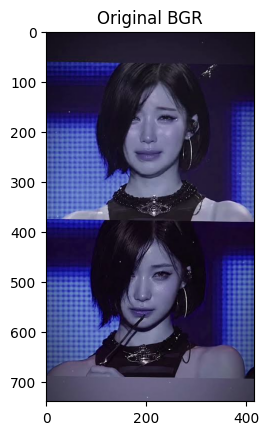

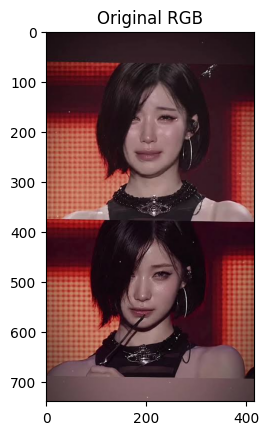

In [ ]:
img = cv2.imread('/content/drive/MyDrive/hpc/images.jpg')
plt.imshow(img)
plt.title("Original BGR")
plt.show()

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title("Original RGB")
plt.show()

In [ ]:
height = img_rgb.shape[0]
width = img_rgb.shape[1]

print("Height:", height)
print("Width:", width)

Height: 739
Width: 415


# 1D Image: GPU Config

REWIND LAB 3 EXPLAINATION:

Old version code:
pixelCount = width * height
blockSize = 64
gridSize = pixelCount / blockSize

call grayscale[gridSize, blockSize] => This function telling to take the exact physical blocks of threads ( Here 14400, but 14400.0 so OOF! => TypeError)



Solution: gridSize = (pixelCount + blockSize - 1) // blockSize return the exact unit of 14400

Time: 1.4871 s


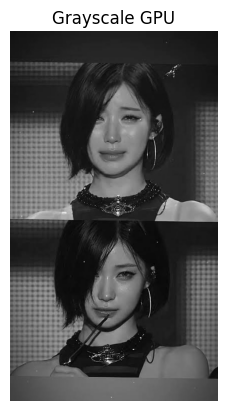

In [ ]:
time_start = time.time()


height = img_rgb.shape[0]
width = img_rgb.shape[1]

pixelCount = width * height
blockSize = 64
# gridSize = pixelCount / blockSize                         <= This is where the float comes to error the program, so YEET
gridSize = (pixelCount + blockSize - 1) // blockSize

src_host = img_rgb.reshape(pixelCount, 3)

@cuda.jit
def grayscale1d(src, dst):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    s = int(src[tidx, 0]) + int(src[tidx, 1]) + int(src[tidx, 2])
    g = np.uint8(s // 3)
    dst[tidx, 0] = g
    dst[tidx, 1] = g
    dst[tidx, 2] = g

devSrc = cuda.to_device(src_host)
devDst = cuda.device_array((pixelCount, 3), np.uint8)

grayscale1d[gridSize, blockSize](devSrc, devDst)
cuda.synchronize()

hostDst = devDst.copy_to_host().reshape(height, width, 3)

time_end = time.time()
print("Time:", round(time_end - time_start, 4), "s")

plt.imshow(hostDst)
plt.title("Grayscale GPU")
plt.axis('off')
plt.show()


# 2D Image: GPU Config

Time: 0.18414 s


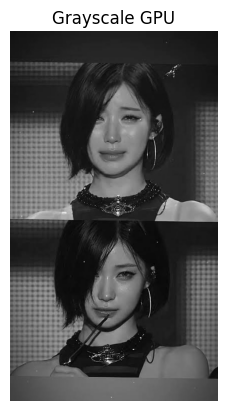

In [ ]:
height, width = img_rgb.shape[:2]  # Take only X and Y => Z Yeet

blockSize = 32 # 32 Block => SM: 32 X n (i.e, Slide 32 x 8 = 126)
blockDim = (blockSize, blockSize) # 32 x 32 block
gridSize = ((width + blockSize - 1) // blockSize,    # x blocks -> width
            (height + blockSize - 1) // blockSize)   # y blocks -> height

@cuda.jit
def grayscale2d(src, dst):
    x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    s = int(src[y, x, 0]) + int(src[y, x, 1]) + int(src[y, x, 2])
    g = np.uint8(s // 3)
    dst[y, x, 0] = g
    dst[y, x, 1] = g
    dst[y, x, 2] = g

devSrc = cuda.to_device(img_rgb)
devDst = cuda.device_array((height, width, 3), np.uint8)

time_start = time.time()
grayscale2d[gridSize, blockDim](devSrc, devDst)
cuda.synchronize()
time_end = time.time()
print("Time:", round(time_end - time_start, 5), "s")

plt.imshow(devDst.copy_to_host())
plt.title("Grayscale GPU")
plt.axis('off')
plt.show()

# Test?, Im braindead today =((

=> next session i will finish the test